In [ ]:
!pip install matplotlib networkx

finding points
drawing points
( 1 , -1 ),( 2 , 4 ),( 0 , 1 ),( -1 , 0 ),( 0 , -2 ),( 0 , 0 ),

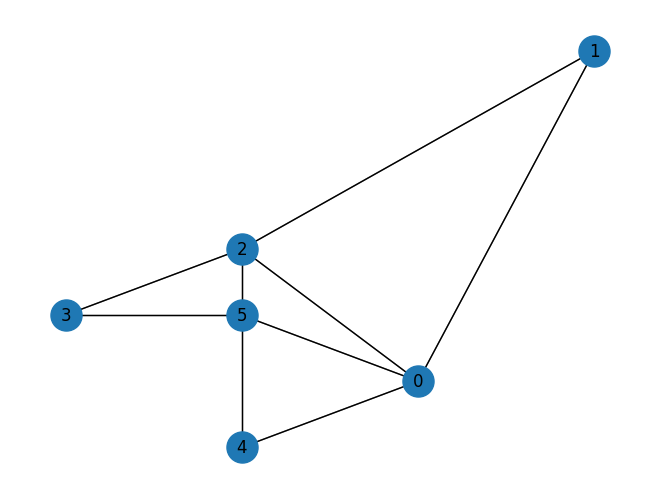

In [2]:
from z3 import *

use_domain_of_ints=True
num,pairs=10,"0-1,0-2,0-5,0-6,1-6,1-8,1-9,2-3,2-4,2-5,3-4,3-7,3-9,4-5,4-9,5-6,7-8,7-9"
num,pairs=6,"0-1,0-2,0-4,0-5,1-2,2-3,2-5,3-5,4-5"
#num,pairs=4,"0-2,0-3,1-2,1-3,2-3"
#num,pairs=6,"0-2,0-3,0-4,0-5,1-2,1-4,2-3,2-4,4-5"
pairs = pairs.split(",")
pairs = [(int(x.split("-")[0]),int(x.split("-")[1])) for x in pairs]

dots=[[Const("dot2_%i" % i,IntSort() if use_domain_of_ints else RealSort()),Const("dot1_%i" % i,IntSort() if use_domain_of_ints else RealSort())] for i in range(num)]

def is_crossing(x1,y1,x2,y2,x3,y3,x4,y4):#precondition d1!=d2 and d3!=d4
    a1,b1,c1,a2,b2,c2,xi,yi = Reals("a1 b1 c1 a2 b2 c2 xi yi") #return false if crossing point is one of endpoints of linesegments
    return Exists([a1,b1,c1,a2,b2,c2,xi,yi],And(
        Not(And(a1==0,b1==0)),
        Not(And(a2==0,b2==0)),
        a1*x1+b1*y1+c1==0,
        a1*x2+b1*y2+c1==0,
        a2*x3+b2*y3+c2==0,
        a2*x4+b2*y4+c2==0,
        a1*xi+b1*yi+c1==0,
        a2*xi+b2*yi+c2==0,
        Not(And(And(x1==xi,y1==yi),And(x3==xi,y3==yi))),#crossing point can not be both of endpoints,but can be one of them 
        Not(And(And(x1==xi,y1==yi),And(x4==xi,y4==yi))),
        Not(And(And(x2==xi,y2==yi),And(x3==xi,y3==yi))),
        Not(And(And(x2==xi,y2==yi),And(x4==xi,y4==yi))),
        Or(And(x1<=xi,xi<=x2),And(x2<=xi,xi<=x1)),#one of coordinates of crossing point can be same as one of endpoint,but two coordinates can not be as stated above  
        Or(And(x3<=xi,xi<=x4),And(x4<=xi,xi<=x3)),
        Or(And(y1<=yi,yi<=y2),And(y2<=yi,yi<=y1)),
        Or(And(y3<=yi,yi<=y4),And(y4<=yi,yi<=y3))
    ))

s = Solver()

# s.add(is_crossing( 4,2, 4,3, 4,2, 4,4 )==True)#should be true
# s.add(is_crossing( 4,2, 4,3, 4,2, 5,2 )==False)#should be false
# s.add(is_crossing( 0,0, 0,1, -1,0, 1,0 )==True)
# s.add(is_crossing( -2,-3, -1,-2, -2,-3, 0,-1 )==True)

#there are no crossing lines
for x in range(len(pairs)):
    for y in range(x+1,len(pairs)):
        pair1=pairs[x]
        pair2=pairs[y]
        d1=dots[pair1[0]]
        d2=dots[pair1[1]]
        d3=dots[pair2[0]]
        d4=dots[pair2[1]]
        s.add(Not(is_crossing(d1[0],d1[1],d2[0],d2[1],d3[0],d3[1],d4[0],d4[1])))


#all points should be different,seems like this one is not neccasery 
for x in range(len(dots)):
    for y in range(x+1,len(dots)):
        d1=dots[x]
        d2=dots[y]
        s.add(Not(And(d1[0]==d2[0],d1[1]==d2[1])))

import matplotlib.pyplot as plt
import networkx as nx

solution=[( 4 , 2 ),( 4 , 3 ),( 4 , 4 ),( 4 , 5 ),( 4 , 6 ),( 4 , 7 )] #should be unsat for  "0-1,0-2,0-4,0-5,1-2,2-3,2-5,3-5,4-5

solution=[ #for "0-2,0-3,1-2,1-3,2-3"
    [0,0],
    [1,1],
    [1,0],
    [0,1]
]
#TODO able to check solution but not able to find after 44min
#able to quickly find if use_domain_of_ints=True
solution=[ #for "0-1,0-2,0-4,0-5,1-2,2-3,2-5,3-5,4-5"
    [0,0],
    [1,0],
    [2,1],
    [2,2],
    [1,1],
    [0,2]
]
solution=[]
for i in range(len(solution)):
    dot = dots[i]
    dot_sol = solution[i]
    s.add(And(dot[0]==dot_sol[0],dot[1]==dot_sol[1]))

while True:
    print("finding points")
    st=s.check()
    if st==sat:
        m = s.model()
        print("drawing points")


        G = nx.Graph()

        for i in range(len(dots)):
            dot = dots[i]
            if use_domain_of_ints:
                x,y = m.eval(dot[0]).as_long(),m.eval(dot[1]).as_long()
            else:
                x,y = m.eval(dot[0]).as_decimal(5),m.eval(dot[1]).as_decimal(5)
            print("(",x,",",y,"),",end="")
            G.add_node(str(i), pos=(x,y))
        for pair in pairs:
            G.add_edge(str(pair[0]), str(pair[1]))
            #print(str(pair[0]), str(pair[1]))
            pass

        pos = nx.get_node_attributes(G, 'pos')
        nx.draw(G, pos, node_size=500, with_labels=True)
        nx.draw_networkx_edges(G, pos, width=1.0, alpha=0.5)
        plt.show()
        break
        s.add(Not(And([m.eval(domino_tilling(x,y))==domino_tilling(x,y)  for y in range(len(domino_field[x])) for x in range(len(domino_field)) ])))

    else:
        print(st)
        break